# Bootes-DESI AGN Comparison
Benjamin Floyd

Pulls galaxies from the DESI DR1 (public) QSOAGN VAC for AGN type comparison against our IR-AGN selection.

In [ ]:
import json
import warnings

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import yaml
from astropy.coordinates import SkyCoord
from astropy.table import Table, hstack, vstack, join, setdiff
from desiutil.bitmask import BitMask
from scipy.interpolate import interp1d
from astropy.cosmology import FlatLambdaCDM

%matplotlib inline

In [ ]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

In [2]:
def one_color_selection(catalog: Table, bins: np.ndarray, zcol: str ='REDSHIFT') -> Table:
    """
    Function to apply our single-color IRAGN selection by redshift.

    Parameters
    ----------
    catalog: Table
        Catalog of magnitude cut AGN candidates with color and redshift information.
    bins: np.ndarray
        Redshift binning to use for the selection.
    zcol: str
        Name of redshift column to use. Default is 'REDSHIFT'.

    Returns
    -------
    Table
        Single-color IRAGN selected catalog.
    """

    iragn_all_zbins = []
    for i, z in enumerate(bins[:-1]):
        # Select only AGN within the redshift bin
        agn_in_zbin = catalog[(bins[i] < catalog[zcol]) & (catalog[zcol] <= bins[i+1])]

        # Get the IR color selection for this redshift bin
        ir_selection_color = agn_purity_color(z)

        # Apply the color selection
        iragn = agn_in_zbin[agn_in_zbin['I1_I2_COLOR'] >= ir_selection_color]
        iragn_all_zbins.append(iragn)

    # Stack the binned subcatalogs back together
    iragn_all_zbins = vstack(iragn_all_zbins)

    return iragn_all_zbins

In [3]:
# Read in the AGN mask bit encoding
with open('/global/cfs/cdirs/desi/public/dr1/vac/dr1/agnqso/v1.0/tutorial/agnmask.yaml', 'r') as f:
    yaml_defs = yaml.safe_load(f)
    
    agn_bitmasks = BitMask('AGN_MASKBITS', yaml_defs)
    opt_uv_type = BitMask('OPT_UV_TYPE', yaml_defs)
    ir_type = BitMask('IR_TYPE', yaml_defs)

In [4]:
agn_bitmasks, opt_uv_type, ir_type

In [5]:
# Read in the file with stored purity color threshold data
with open('/pscratch/sd/b/bfloyd/SDWFS_purity_color_4.5_17.48.json', 'r') as f:
    purity_data = json.load(f)
z_bins = np.array(purity_data['redshift_bins'])
color_bins = purity_data['color_bins']
purity_90_color = purity_data['purity_90_colors']
purity_92_color = purity_data['purity_92_colors']
purity_95_color = purity_data['purity_95_colors']

agn_purity_color = interp1d(z_bins[:-1], purity_90_color, kind='previous')

(AGN_MASKBITS:
   - [AGN_ANY,          0, "any AGN classification is set"]
   - [RR,               1, "RR determines this to be a QSO from template fitting"]
   - [MGII,             2, "MgII afterburner detects broad line"]
   - [QN,               3, "Quasar Net reclassifies as a QSO"]
   - [QN_NEW_RR,        4, "Quasar Net prompts different RR redshift"]
   - [QN_BGS,           5, "Quasar Net reclassifies BGS target as a QSO"]
   - [QN_ELG,           6, "Quasar Net reclassifies ELG target as a QSO"]
   - [QN_VAR_WISE,      7, "Quasar Net reclassifies VAR_WISE_QSO target as a QSO"]
   - [BPT_ANY_SY,      10, "At least one BPT diagnostic indicates SEYFERT (robust AGN)"]
   - [BPT_ANY_AGN,     11, "At least one BPT diagnostic indicates SEYFERT, LINER or COMPOSITE"]
   - [BROAD_LINE,      12, "Lines with FWHM >=1200 km/s in Halpha, Hbeta, MgII and/or CIV line"]
   - [OPT_OTHER_AGN,   13, "Rest frame optical emission lines diagnostic not BPT (4000-10000 ang) indicate AGN"]
   - [UV,       

In [6]:
# Read in the DESI AGNQSO VAC
desi_agn = Table.read('/global/cfs/cdirs/desi/public/dr1/vac/dr1/agnqso/v1.0/agnqso_desi.fits', hdu='AGNCAT')

# Also read in the flux data for the AGNQSO VAC
with warnings.catch_warnings():
    warnings.simplefilter('ignore', u.UnitsWarning)
    desi_agn_flux = Table.read('/global/cfs/cdirs/desi/public/dr1/vac/dr1/agnqso/v1.0/agnqso_desi.fits', hdu='AUXDATA')

# Read in the SDWFS-IRAGN catalog
sdwfs_iragn = Table.read('/pscratch/sd/b/bfloyd/SDWFS_full-field_IRAGN.fits')

In [7]:
# desi_agn_full = join(desi_agn, desi_agn_flux, keys=['TARGETID', 'SURVEY', 'PROGRAM'], metadata_conflicts='silent')

In [8]:
# desi_agn_test_target = desi_agn_full[desi_agn_full['TARGETID'] == 39632931026635417]
# desi_agn_test_target.write('bfloyd/DESI-AGN-VAC_TID-39632931026635417.csv')

In [9]:
# desi_agn_test_target

In [10]:
# for i, entry in enumerate(desi_agn_test_target['OPT_UV_TYPE']):
#     print(f'{desi_agn_test_target["SURVEY"][i]}')
#     for name in opt_uv_type.names():
#         if entry & opt_uv_type[name] != 0:
#             print(f'{opt_uv_type.comment(name)}')

In [11]:
# For convenience, make a new column for just the [3.6] - [4.5] color
sdwfs_iragn['I1_I2_COLOR'] = sdwfs_iragn['I1_MAG_APER4'] - sdwfs_iragn['I2_MAG_APER4']

In [12]:
with np.errstate(divide='ignore', invalid='ignore'):
    # Convert the WISE fluxes (in nanomaggies) into AB magnitudes
    desi_agn_flux['ABMAG_W1'] = -2.5 * np.log10(desi_agn_flux['FLUX_W1']) + 22.5
    desi_agn_flux['ABMAG_W2'] = -2.5 * np.log10(desi_agn_flux['FLUX_W2']) + 22.5
    desi_agn_flux['ABMAG_W3'] = -2.5 * np.log10(desi_agn_flux['FLUX_W3']) + 22.5

    # Now convert to Vega magnitudes
    desi_agn_flux['VegaMAG_W1'] = desi_agn_flux['ABMAG_W1'] - 2.699
    desi_agn_flux['VegaMAG_W2'] = desi_agn_flux['ABMAG_W2'] - 3.339
    desi_agn_flux['VegaMAG_W3'] = desi_agn_flux['ABMAG_W3'] - 5.174

    # Make a W1-W2 color (Vega) column
    desi_agn_flux['Vega_W1_W2'] = desi_agn_flux['VegaMAG_W1'] - desi_agn_flux['VegaMAG_W2']

    # Finally, make the SNRs for the three bands
    desi_agn_flux['SNR_W1'] = desi_agn_flux['FLUX_W1'] / np.sqrt(desi_agn_flux['FLUX_IVAR_W1'])
    desi_agn_flux['SNR_W2'] = desi_agn_flux['FLUX_W2'] / np.sqrt(desi_agn_flux['FLUX_IVAR_W2'])
    desi_agn_flux['SNR_W3'] = desi_agn_flux['FLUX_W3'] / np.sqrt(desi_agn_flux['FLUX_IVAR_W3'])

In [13]:
# Create coordinates
desi_coords = SkyCoord(desi_agn['TARGET_RA'], desi_agn['TARGET_DEC'], unit=u.deg)
sdwfs_coords = SkyCoord(sdwfs_iragn['ALPHA_J2000'], sdwfs_iragn['DELTA_J2000'], unit=u.deg)

In [14]:
# Match the catalogs
desi_idx, sep, _ = sdwfs_coords.match_to_catalog_sky(desi_coords)

In [15]:
# Select the matches
max_sep = 1 * u.arcsec
sdwfs_iragn_matches = sdwfs_iragn[sep <= max_sep]
desi_agn_matches = desi_agn[desi_idx[sep <= max_sep]]

sdwfs_desi_agn = hstack([sdwfs_iragn_matches, desi_agn_matches])

# Also join the flux columns
sdwfs_desi_agn = join(sdwfs_desi_agn, desi_agn_flux, keys=['TARGETID', 'SURVEY', 'PROGRAM'], join_type='left', metadata_conflicts='silent')

In [16]:
print(f'Fraction of SDWFS sources with DESI AGN counterparts: {len(sdwfs_desi_agn)/len(sdwfs_iragn):.1%}')

In [17]:
sdwfs_desi_agn[(sdwfs_desi_agn['SPECTYPE'] != 'GALAXY') & (sdwfs_desi_agn['SPECTYPE'] != 'QSO')]['SPECTYPE']

Fraction of SDWFS sources with DESI AGN counterparts: 11.8%


In [18]:
sdwfs_desi_iragn = one_color_selection(sdwfs_desi_agn, z_bins, zcol='REDSHIFT')

STAR


In [19]:
# For visual comparison, apply the Assef+13 AGN selection to compare the phot-z and spec-z's
alpha_r90 = 0.662
beta_r90 = 0.232
gamma_r90 = 13.97
sdwfs_desi_a13agn = sdwfs_desi_agn[(sdwfs_desi_agn['VegaMAG_W2'] < 16.41) & (sdwfs_desi_agn['Vega_W1_W2'] > alpha_r90 * np.exp(beta_r90 * (sdwfs_desi_agn['VegaMAG_W2'] - gamma_r90)**2))]

In [20]:
len(sdwfs_desi_a13agn)

## Redshift Comparison

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))
# ax.scatter(sdwfs_desi_agn['Z'], sdwfs_desi_agn['REDSHIFT'], marker='.')
# ax.scatter(sdwfs_desi_iragn['Z'], sdwfs_desi_iragn['REDSHIFT'], marker='.', alpha=0.4, label='Single-Color IR AGN')
ax.scatter(sdwfs_desi_a13agn['Z'], sdwfs_desi_a13agn['REDSHIFT'], marker='.', label='Assef+13 AGN Sample')
ax.axline(xy1=(0, 0), slope=1, c='k')
# for z in z_bins[:-1]:
#     ax.axhline(y=z, ls='--', c='k', alpha=0.2)
ax.legend()
ax.set(ylabel='SDWFS Photo-z', xlabel='DESI Spec-z', xlim=[0, 6], ylim=[0, 6])
# fig.savefig('/pscratch/sd/b/bfloyd/SDWFS-DESI_Assef+13_AGN_specz-photz.pdf')

[Text(0, 0.5, 'SDWFS Photo-z'),
 Text(0.5, 0, 'DESI Spec-z'),
 (0.0, 6.0),
 (0.0, 6.0)]

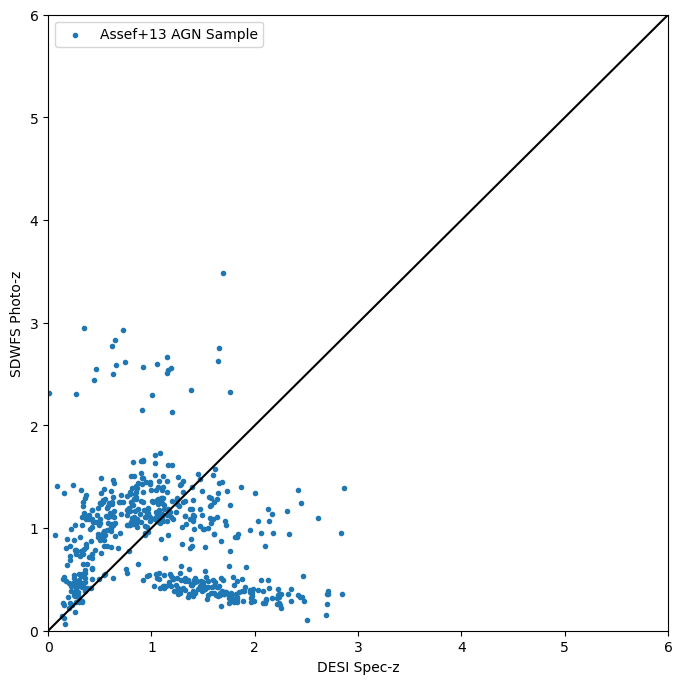

In [44]:
fig, (ax, bx) = plt.subplots(ncols=2, sharey='row', figsize=(6.4 * 2, 4.8), layout='constrained')
ax.scatter(sdwfs_desi_agn['REDSHIFT'], sdwfs_desi_agn['I1_I2_COLOR'], marker='.', s=5)
ax.scatter(sdwfs_desi_iragn['REDSHIFT'], sdwfs_desi_iragn['I1_I2_COLOR'], marker='.', s=5, label='Single Color IR AGN')
ax.step(z_bins[:-1], purity_90_color, where='post', c='k')
ax.legend()
ax.set(xlabel='Photo-z', ylabel='[3.6] - [4.5] (Vega)', xlim=[0, 3])

bx.scatter(sdwfs_desi_agn['Z'], sdwfs_desi_agn['I1_I2_COLOR'], marker='.', s=5)
bx.scatter(sdwfs_desi_iragn['Z'], sdwfs_desi_iragn['I1_I2_COLOR'], marker='.', s=5, label='Single Color IR AGN')
bx.step(z_bins[:-1], purity_90_color, where='post', c='k')
bx.legend()
bx.set(xlabel='Spec-z', xlim=[0, 3])
# fig.savefig('/pscratch/sd/b/bfloyd/SDWFS-DESI_AGN_color-redshifts.pdf')

## Spectral Type Classifications

In [ ]:
sdwfs_desi_agn_bl = sdwfs_desi_agn[sdwfs_desi_agn['AGN_MASKBITS'] & agn_bitmasks.BROAD_LINE != 0]
sdwfs_desi_agn_bpt_sey = sdwfs_desi_agn[sdwfs_desi_agn['AGN_MASKBITS'] & agn_bitmasks.BPT_ANY_SY != 0]
sdwfs_desi_agn_bpt_agn = sdwfs_desi_agn[sdwfs_desi_agn['AGN_MASKBITS'] & agn_bitmasks.BPT_ANY_AGN != 0]

In [24]:
fig, ax = plt.subplots()
ax.scatter(sdwfs_desi_agn['REDSHIFT'], sdwfs_desi_agn['I1_I2_COLOR'], marker='.')
ax.scatter(sdwfs_desi_iragn['REDSHIFT'], sdwfs_desi_iragn['I1_I2_COLOR'], marker='.', label='Single Color IR AGN')
ax.scatter(sdwfs_desi_agn_bl['REDSHIFT'], sdwfs_desi_agn_bl['I1_I2_COLOR'], marker='.', label='DESI Broad-line')
ax.scatter(sdwfs_desi_agn_bpt_agn['REDSHIFT'], sdwfs_desi_agn_bpt_agn['I1_I2_COLOR'], marker='.', label='DESI BPT (any) AGN')
ax.scatter(sdwfs_desi_agn_bpt_sey['REDSHIFT'], sdwfs_desi_agn_bpt_sey['I1_I2_COLOR'], marker='.', label='DESI BPT (any) Sey')
ax.step(z_bins[:-1], purity_90_color, where='post', c='k')
ax.legend()
ax.set(xlabel='Photo-z', ylabel='[3.6] - [4.5] (Vega)', xlim=[0, 1.8], ylim=[0, 1.5])
# fig.savefig('/pscratch/sd/b/bfloyd/SDWFS-DESI_AGN_BL+BPT.pdf')

[Text(0.5, 0, 'Photo-z'),
 Text(0, 0.5, '[3.6] - [4.5] (Vega)'),
 (0.0, 1.8),
 (0.0, 1.5)]

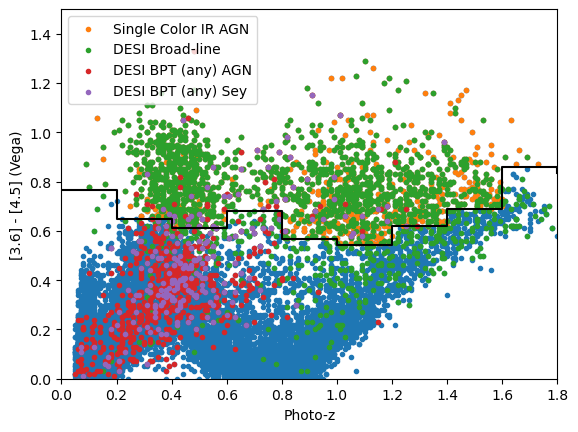

In [25]:
sdwfs_desi_agn_bl_iragn = one_color_selection(sdwfs_desi_agn_bl, z_bins, zcol='REDSHIFT')
print(f'Fraction of Broad-line AGN selected as (single color) IR-AGN: {len(sdwfs_desi_agn_bl_iragn) / len(sdwfs_desi_iragn):.1%}')

In [26]:
# Look at a BPT diagram of the IR AGN galaxies
xx = np.linspace(-3, 3, num=1000)

# [NII] boundary lines
kew01_nii = 0.61 / (xx - 0.47) + 1.19
kauf03 = 0.61 / (xx - 0.05) + 1.3
scha07 = 1.05 * xx + 0.45
# Filter out the regions where not valid
kew01_nii[xx >= 0.47] = np.nan
kauf03[xx >= 0.05] = np.nan
scha07[scha07 < kew01_nii] = np.nan

# [SII] boundary lines
kew01_sii = 0.72 / (xx - 0.32) + 1.3
kew06_sii = 1.89 * xx + 0.76
law21_sii = 0.648 / (xx - 0.324) + 1.43
# Filter out the regions where not valid
kew01_sii[xx >= 0.32] = np.nan
law21_sii[xx >= 0.324] = np.nan
kew06_sii[kew06_sii < law21_sii] = np.nan

# [OI] boundary lines
kew01_oi = 0.73 / (xx + 0.59) + 1.33
kew06_oi = 1.18 * xx + 1.3
law21_oi = 0.884 / (xx + 0.124) + 1.4
# Filter out the regions where not valid
kew01_oi[xx >= -0.59] = np.nan
law21_oi[xx >= -0.124] = np.nan
kew06_oi[kew06_oi < law21_oi] = np.nan


with np.errstate(divide='ignore', invalid='ignore'):
    xx_bptnii = np.log10(sdwfs_desi_iragn['NII_6584_FLUX'] / sdwfs_desi_iragn['HALPHA_FLUX'])
    xx_bptsii = np.log10((sdwfs_desi_iragn['SII_6716_FLUX'] + sdwfs_desi_iragn['SII_6731_FLUX']) / sdwfs_desi_iragn['HALPHA_FLUX'])
    xx_bptoi = np.log10(sdwfs_desi_iragn['OI_6300_FLUX'] / sdwfs_desi_iragn['HALPHA_FLUX'])
    yy_bpt = np.log10(sdwfs_desi_iragn['OIII_5007_FLUX'] / sdwfs_desi_iragn['HBETA_FLUX'])

# Set masks
ir_bptnii_sf_mask = sdwfs_desi_iragn['OPT_UV_TYPE'] & opt_uv_type.NII_SF != 0
ir_bptnii_comp_mask = sdwfs_desi_iragn['OPT_UV_TYPE'] & opt_uv_type.NII_COMP !=0
ir_bptnii_sey_mask = sdwfs_desi_iragn['OPT_UV_TYPE'] & opt_uv_type.NII_SY != 0
ir_bptnii_liner_mask = sdwfs_desi_iragn['OPT_UV_TYPE'] & opt_uv_type.NII_LINER != 0

ir_bptsii_sf_mask = sdwfs_desi_iragn['OPT_UV_TYPE'] & opt_uv_type.SII_SF != 0
ir_bptsii_sey_mask = sdwfs_desi_iragn['OPT_UV_TYPE'] & opt_uv_type.SII_SY != 0
ir_bptsii_liner_mask = sdwfs_desi_iragn['OPT_UV_TYPE'] & opt_uv_type.SII_LINER != 0

ir_bptoi_sf_mask = sdwfs_desi_iragn['OPT_UV_TYPE'] & opt_uv_type.OI_SF != 0
ir_bptoi_sey_mask = sdwfs_desi_iragn['OPT_UV_TYPE'] & opt_uv_type.OI_SY != 0
ir_bptoi_liner_mask = sdwfs_desi_iragn['OPT_UV_TYPE'] & opt_uv_type.OI_LINER != 0

fig, axes = plt.subplots(ncols=3, sharey=True, figsize=(6.4 * 3, 4.8), layout='constrained')
axes[0].scatter(xx_bptnii[ir_bptnii_sf_mask], yy_bpt[ir_bptnii_sf_mask], marker='.', c='tab:blue', label='Star Forming')
axes[0].scatter(xx_bptnii[ir_bptnii_sey_mask], yy_bpt[ir_bptnii_sey_mask], marker='.', c='tab:orange', label='Seyfert')
axes[0].scatter(xx_bptnii[ir_bptnii_comp_mask], yy_bpt[ir_bptnii_comp_mask], marker='.', c='tab:green', label='Composite')
axes[0].scatter(xx_bptnii[ir_bptnii_liner_mask], yy_bpt[ir_bptnii_liner_mask], marker='.', c='tab:red', label='LINER')

axes[1].scatter(xx_bptsii[ir_bptsii_sf_mask], yy_bpt[ir_bptsii_sf_mask], marker='.', c='tab:blue', label='Star Forming')
axes[1].scatter(xx_bptsii[ir_bptsii_sey_mask], yy_bpt[ir_bptsii_sey_mask], marker='.', c='tab:orange', label='Seyfert')
axes[1].scatter(xx_bptsii[ir_bptsii_liner_mask], yy_bpt[ir_bptsii_liner_mask], marker='.', c='tab:red', label='LINER')

axes[2].scatter(xx_bptoi[ir_bptoi_sf_mask], yy_bpt[ir_bptoi_sf_mask], marker='.', c='tab:blue', label='Star Forming')
axes[2].scatter(xx_bptoi[ir_bptoi_sey_mask], yy_bpt[ir_bptoi_sey_mask], marker='.', c='tab:orange', label='Seyfert')
axes[2].scatter(xx_bptoi[ir_bptoi_liner_mask], yy_bpt[ir_bptoi_liner_mask], marker='.', c='tab:red', label='LINER')

# [NII] BPT Lines
axes[0].plot(xx, kew01_nii, c='k', label='Kauffmann+03')
axes[0].plot(xx, kauf03, c='k', label='Kewley+01')
axes[0].plot(xx, scha07, c='k', label='Law+21')

# [SII] BPT Lines
# axes[1].plot(xx, kew01_sii, c='k', label='Kewley+01')
axes[1].plot(xx, kew06_sii, c='k', label='Kewley+06')
axes[1].plot(xx, law21_sii, c='k', label='Law+21')


# axes[2].plot(xx, kew01_oi, c='k', label='Kewley+01')
axes[2].plot(xx, kew06_oi, c='k', label='Kewley+06')
axes[2].plot(xx, law21_oi, c='k', label='Law+21')

axes[0].legend()

axes[0].set(xlabel=r'$\log(\mathrm{[NII]}/\mathrm{H\alpha})$', ylabel=r'$\log(\mathrm{[OIII]}/\mathrm{H\beta})$', ylim=[-1.6, 2], xlim=[-1.5, 1])
axes[1].set(xlabel=r'$\log(\mathrm{[SII]}/\mathrm{H\alpha})$', xlim=[-2, 0.5])
axes[2].set(xlabel=r'$\log(\mathrm{[OI]}/\mathrm{H\alpha})$', xlim=[-3, 0.5])
# fig.savefig('/pscratch/sd/b/bfloyd/SDWFS-DESI_AGN_BPT.pdf')

Fraction of Broad-line AGN selected as (single color) IR-AGN: 78.0%


[Text(0.5, 0, '$\\log(\\mathrm{[OI]}/\\mathrm{H\\alpha})$'), (-3.0, 0.5)]

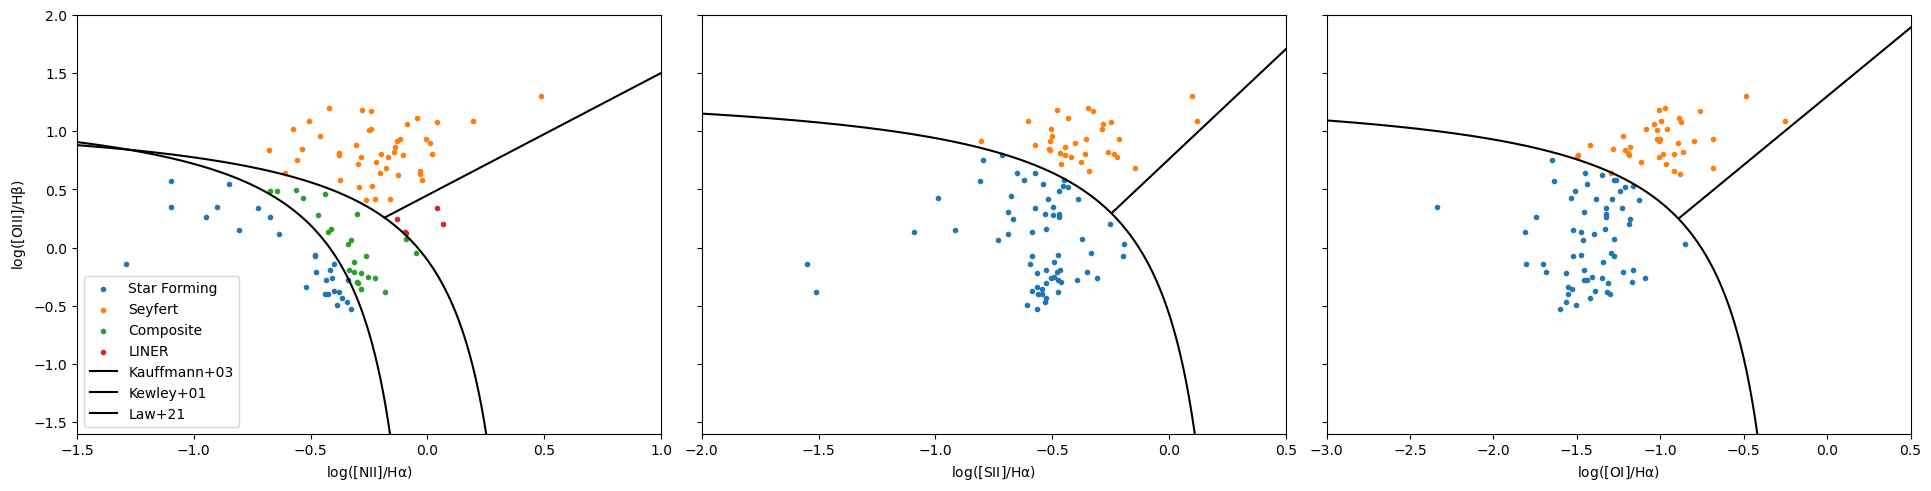

In [27]:
ir_a18_r90_mask = sdwfs_desi_iragn['IR_TYPE'] & ir_type.WISE_AGN_A18 != 0

fig, ax = plt.subplots()
ax.scatter(sdwfs_desi_iragn['I1_MAG_APER4'], sdwfs_desi_iragn['I1_I2_COLOR'], marker='.', label='All SDWFS–DESI IRAGN')
ax.scatter(sdwfs_desi_iragn['I2_MAG_APER4'][ir_a18_r90_mask], sdwfs_desi_iragn['I1_I2_COLOR'][ir_a18_r90_mask], marker='.', label='Asseff+18 Selection')
ax.legend()
ax.set(xlabel='[4.5] (Vega mag)', ylabel='[3.6] - [4.5] (Vega)')
# fig.savefig('/pscratch/sd/b/bfloyd/SDWFS-DESI_AGN_Assef+18.pdf')

[Text(0.5, 0, '[4.5] (Vega mag)'), Text(0, 0.5, '[3.6] - [4.5] (Vega)')]

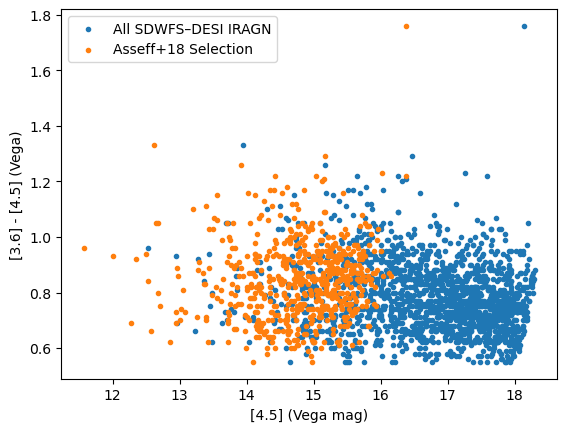

In [28]:
print(f'Fraction of IR-AGN satisfying the Assef+18 WISE selection: {len(sdwfs_desi_iragn[ir_a18_r90_mask])/len(sdwfs_desi_iragn):.1%}')

## Exploring BL-AGN and complement subsamples

In [ ]:
sdwfs_desi_agn_bl_iragn = sdwfs_desi_iragn[sdwfs_desi_iragn['AGN_MASKBITS'] & agn_bitmasks.BROAD_LINE != 0]
sdwfs_desi_agn_nonbl_iragn = sdwfs_desi_iragn[sdwfs_desi_iragn['AGN_MASKBITS'] & agn_bitmasks.BROAD_LINE == 0]

In [30]:
len(sdwfs_desi_agn_nonbl_iragn)

In [31]:
assert len(sdwfs_desi_agn_bl_iragn) + len(sdwfs_desi_agn_nonbl_iragn) == len(sdwfs_desi_iragn)

381

In [32]:
len(sdwfs_desi_iragn)

In [33]:
len(sdwfs_desi_agn_bl_iragn) + len(sdwfs_desi_agn_nonbl_iragn)

1734

1734

## $L_{[OIII]} - L_X$ ratios

In [ ]:
# Read in the SDWFS–CDWFS matched catalog
sdwfs_cdwfs_xagn = Table.read('bfloyd/SDWFS-CDWFS_XAGN_matches.fits')

In [ ]:
sdwfs_cdwfs_xagn.colnames

In [ ]:
# Join the CDWFS catalog with the DESI catalog
sdwfs_desi_cdwfs_xagn_iragn = join(sdwfs_desi_iragn, sdwfs_cdwfs_xagn, join_type='left')

In [ ]:
sdwfs_desi_cdwfs_xagn_iragn.colnames

In [ ]:
# Convert the [O III] flux into luminosity
sdwfs_desi_cdwfs_xagn_iragn['OIII_5007_LUM'] = 4 * np.pi * cosmo.luminosity_distance(sdwfs_desi_cdwfs_xagn_iragn['Z']).to(u.cm)**2 * sdwfs_desi_cdwfs_xagn_iragn['OIII_5007_FLUX'] * 1e-17

In [ ]:
# Compton thickness ratio
sdwfs_desi_cdwfs_xagn_iragn['logT'] = np.log10(sdwfs_desi_cdwfs_xagn_iragn['L2-10'] / sdwfs_desi_cdwfs_xagn_iragn['OIII_5007_LUM'])

In [ ]:
fig, ax = plt.subplots()
ax.hist(sdwfs_desi_cdwfs_xagn_iragn['logT'], bins=np.arange(-1, 3, 0.1), range=[-1, 3])
ax.set(xlabel=r'$\log T = \log(L_{2-10~\mathrm{keV}} / L_{\mathrm{[O III]}})$')

In [ ]:
l_bins = np.arange(35, 46.5, 0.25)
fig, (ax, bx) = plt.subplots(nrows=2, sharex='col')
ax.hist(np.log10(sdwfs_desi_cdwfs_xagn_iragn['OIII_5007_LUM']), bins=l_bins)
ax.set(xlabel=r'$\log L_{\mathrm{[O III]}}$ [erg s$^{-1}$]')

bx.hist(np.log10(sdwfs_desi_cdwfs_xagn_iragn['L2-10']), bins=l_bins)
bx.set(xlabel=r'$\log L_{2-10~\mathrm{keV}}$ [erg s$^{-1}$]')

## $L_{[OIII]} - L_X$ ratios

In [35]:
# Read in the SDWFS–CDWFS matched catalog
sdwfs_cdwfs_xagn = Table.read('bfloyd/SDWFS-CDWFS_XAGN_matches.fits')

In [36]:
sdwfs_cdwfs_xagn.colnames

['Seq',
 'RAdeg',
 'DEdeg',
 'ePos',
 'Fprob',
 'Fr90',
 'Ftot',
 'Fbkg',
 'Fnet',
 'E_Fnet',
 'e_Fnet',
 'Fexp',
 'FCR',
 'E_FCR',
 'e_FCR',
 'FFlux',
 'E_FFlux',
 'e_FFlux',
 'Sprob',
 'Sr90',
 'Stot',
 'Sbkg',
 'Snet',
 'E_Snet',
 'e_Snet',
 'Sepx',
 'SCR',
 'E_SCR',
 'e_SCR',
 'SFlux',
 'E_SFlux',
 'e_SFlux',
 'Hprob',
 'Hr90',
 'Htot',
 'Hbkg',
 'Hnet',
 'E_Hnet',
 'e_Hnet',
 'Hexp',
 'HCR',
 'E_HCR',
 'e_HCR',
 'HFlux',
 'E_HFlux',
 'e_HFlux',
 'HR',
 'E_HR',
 'e_HR',
 'K05',
 'CXOXB',
 'SepK05',
 'Nxb',
 'RANdeg',
 'DENdeg',
 'Imag',
 'RASdeg',
 'DESdeg',
 '3.6mag',
 '4.5mag',
 '5.8mag',
 '8mag',
 'e_3.6mag',
 'e_4.5mag',
 'e_5.8mag',
 'e_8mag',
 'SDWFS',
 'SepN',
 'SepS',
 'SepSN',
 'SepMax',
 'Ncat',
 'PBay',
 'PPost',
 'BiasI',
 'Bias3.6',
 'Psing',
 'Pany',
 'zsp',
 'zphot',
 'b_zphot',
 'B_zphot',
 'Deep',
 'D20',
 'zbest',
 'f_zbest',
 'logNH',
 'E_logNH',
 'e_logNH',
 'Fkcor',
 'b_Fkcor',
 'B_Fkcor',
 'Skcor',
 'b_Skcor',
 'B_Skcor',
 'Hkcor',
 'b_Hkcor',
 'B_Hkcor',
 'FL

In [37]:
# Join the CDWFS catalog with the DESI catalog
sdwfs_desi_cdwfs_xagn_iragn = join(sdwfs_desi_iragn, sdwfs_cdwfs_xagn, join_type='left')

In [38]:
sdwfs_desi_cdwfs_xagn_iragn.colnames

['ID',
 'ALPHA_J2000',
 'DELTA_J2000',
 'I1_FLUX_APER4',
 'I2_FLUX_APER4',
 'I3_FLUX_APER4',
 'I4_FLUX_APER4',
 'I1_FLUXERR_APER4',
 'I2_FLUXERR_APER4',
 'I3_FLUXERR_APER4',
 'I4_FLUXERR_APER4',
 'I1_MAG_APER4',
 'I2_MAG_APER4',
 'I3_MAG_APER4',
 'I4_MAG_APER4',
 'I1_MAGERR_APER4',
 'I2_MAGERR_APER4',
 'I3_MAGERR_APER4',
 'I4_MAGERR_APER4',
 'MASK_NAME',
 'SELECTION_MEMBERSHIP_0.77',
 'SELECTION_MEMBERSHIP_0.65',
 'SELECTION_MEMBERSHIP_0.61',
 'SELECTION_MEMBERSHIP_0.68',
 'SELECTION_MEMBERSHIP_0.57',
 'SELECTION_MEMBERSHIP_0.54',
 'SELECTION_MEMBERSHIP_0.62',
 'SELECTION_MEMBERSHIP_0.69',
 'SELECTION_MEMBERSHIP_0.86',
 'SELECTION_MEMBERSHIP_0.84',
 'REDSHIFT',
 'J_ABS_MAG',
 'COMPLETENESS_CORRECTION',
 'I1_I2_COLOR',
 'TARGETID',
 'SURVEY',
 'PROGRAM',
 'HEALPIX',
 'Z',
 'ZERR',
 'ZWARN',
 'SPECTYPE',
 'AGN_MASKBITS',
 'OPT_UV_TYPE',
 'IR_TYPE',
 'COADD_FIBERSTATUS',
 'TARGET_RA',
 'TARGET_DEC',
 'LS_ID',
 'MIN_MJD',
 'MEAN_MJD',
 'MAX_MJD',
 'COADD_NUMEXP',
 'COADD_EXPTIME',
 'SV_PRI

In [39]:
# Convert the [O III] flux into luminosity
sdwfs_desi_cdwfs_xagn_iragn['OIII_5007_LUM'] = 4 * np.pi * cosmo.luminosity_distance(sdwfs_desi_cdwfs_xagn_iragn['Z']).to(u.cm)**2 * sdwfs_desi_cdwfs_xagn_iragn['OIII_5007_FLUX'] * 1e-17

In [40]:
# Compton thickness ratio
sdwfs_desi_cdwfs_xagn_iragn['logT'] = np.log10(sdwfs_desi_cdwfs_xagn_iragn['L2-10'] / sdwfs_desi_cdwfs_xagn_iragn['OIII_5007_LUM'])

[Text(0.5, 0, '$\\log T = \\log(L_{2-10~\\mathrm{keV}} / L_{\\mathrm{[O III]}})$')]

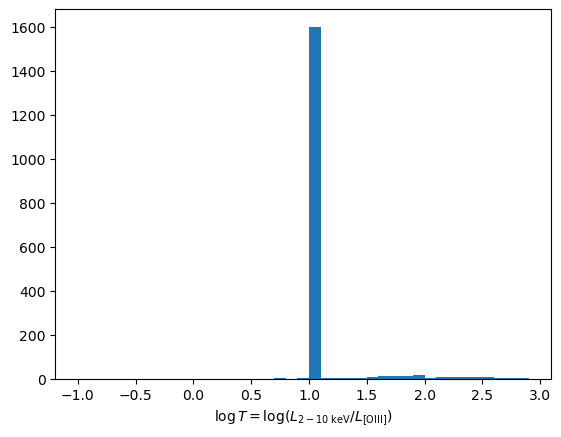

In [41]:
fig, ax = plt.subplots()
ax.hist(sdwfs_desi_cdwfs_xagn_iragn['logT'], bins=np.arange(-1, 3, 0.1), range=[-1, 3])
ax.set(xlabel=r'$\log T = \log(L_{2-10~\mathrm{keV}} / L_{\mathrm{[O III]}})$')

/tmp/ipykernel_673775/3746763953.py:3: RuntimeWarning: divide by zero encountered in log10
  ax.hist(np.log10(sdwfs_desi_cdwfs_xagn_iragn['OIII_5007_LUM']), bins=l_bins)


[Text(0.5, 0, '$\\log L_{2-10~\\mathrm{keV}}$ [erg s$^{-1}$]')]

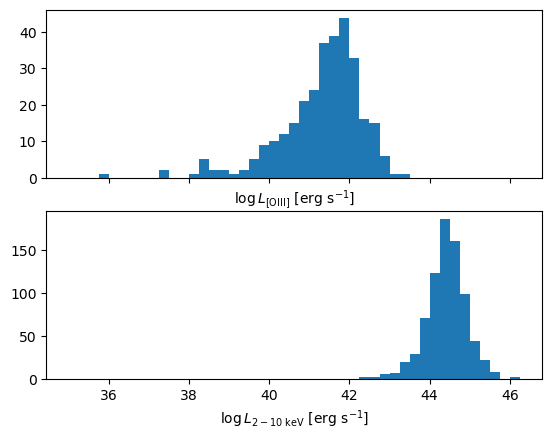

In [51]:
l_bins = np.arange(35, 46.5, 0.25)
fig, (ax, bx) = plt.subplots(nrows=2, sharex='col')
ax.hist(np.log10(sdwfs_desi_cdwfs_xagn_iragn['OIII_5007_LUM']), bins=l_bins)
ax.set(xlabel=r'$\log L_{\mathrm{[O III]}}$ [erg s$^{-1}$]')

bx.hist(np.log10(sdwfs_desi_cdwfs_xagn_iragn['L2-10']), bins=l_bins)
bx.set(xlabel=r'$\log L_{2-10~\mathrm{keV}}$ [erg s$^{-1}$]')